# Neuruak Networks

Содержание:
1. Загрузка данных
2. MLP
3. Hybrid NeuralCF
4. Сравнение моделей и анализ лучшей
5. Артефакты
6. Заключение

## 1. Подготовка данных

### 1.1. Импорты

In [1]:
import os

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler

import torch
from torch.utils.data import TensorDataset, DataLoader

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

### 1.2. Загрузка

In [2]:
data_path = os.path.join('..', 'data', 'ml-latest-small')

# Загружаем подготовленные датасеты
train_df = pd.read_csv(os.path.join(data_path, 'train.csv'))
val_df = pd.read_csv(os.path.join(data_path, 'val.csv'))
test_df = pd.read_csv(os.path.join(data_path, 'test.csv'))

print(f'train {train_df.shape}')
print(f'val {val_df.shape}')
print(f'test {test_df.shape}')

train (70584, 44)
val (10084, 44)
test (20168, 44)


### 1.3. Преобразуем данные под torch

In [3]:
drop_cols = [
    "rating",
    "timestamp",
    "userId",
    "movieId"
]

features = [
    col for col in train_df.columns
    if col not in drop_cols
]

# Убираем ненужные колонки и приводим к типу float32
X_train = train_df[features].values.astype("float32")
y_train = train_df["rating"].values.astype("float32")

X_val = val_df[features].values.astype("float32")
y_val = val_df["rating"].values.astype("float32")

X_test = test_df[features].values.astype("float32")
y_test = test_df["rating"].values.astype("float32")

# Масштабируем признаки

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train).astype("float32")
X_val_scaled = scaler.transform(X_val).astype("float32")
X_test_scaled = scaler.transform(X_test).astype("float32")

# Переводим в тензоры

X_train_tensor = torch.tensor(X_train_scaled)
y_train_tensor = torch.tensor(y_train).view(-1, 1)

X_val_tensor = torch.tensor(X_val_scaled)
y_val_tensor = torch.tensor(y_val).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled)
y_test_tensor = torch.tensor(y_test).view(-1, 1)

### 1.4. DataLoader

In [4]:
train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=1024,
    shuffle=True,
)

val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=4096,
    shuffle=False,
)

test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=4096,
    shuffle=False,
)

## 2. MLP

### 2.1. Импорты

In [5]:
import time
import math
import matplotlib.pyplot as plt

from torch import nn

### 2.2. Класс модели

In [6]:
class RatingMLP(nn.Module):
    def __init__(self, n_features):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),

            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)

### 2.3. Вспомогательные функции

In [15]:
def regression_metrics(preds: torch.Tensor, y_true: torch.Tensor) -> tuple[float, float]:
    """
    Считает RMSE и MAE для предсказаний модели.
    Параметры:
       preds - предсказания модели
       y_true - настоящие результаты
    Возвращает:
        rmse
        mae
    """

    preds = torch.clamp(preds, 0.5, 5.0)

    mse = torch.mean((preds - y_true) ** 2)
    rmse = torch.sqrt(mse)

    mae = torch.mean(torch.abs(preds - y_true))

    return rmse.item(), mae.item()

def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    функция обучения одной эпохи
    Параметры:
        model - модель
        loader - train-загрузчик
        optimizer - оптимизатор
        criterion - функция потерь
        device - устройство (cpu/cuda)
    Возвращает:
        avg_loss
        rmse
        mae
    """
    
    model.train()

    total_loss = 0.0
    total_squared_error = 0.0
    total_absolute_error = 0.0
    total_seen = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)

        preds = model(x)
        loss = criterion(preds, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        with torch.no_grad():
            clipped_preds = torch.clamp(preds, 0.5, 5.0)

            bs = y.size(0)

            squared_error = torch.sum((clipped_preds - y) ** 2).item()
            absolute_error = torch.sum(torch.abs(clipped_preds - y)).item()

            total_loss += loss.item() * bs
            total_squared_error += squared_error
            total_absolute_error += absolute_error
            total_seen += bs

    avg_loss = total_loss / total_seen
    rmse = math.sqrt(total_squared_error / total_seen)
    mae = total_absolute_error / total_seen

    return avg_loss, rmse, mae

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """
    Функция оценки для val и test. train_one_epoch без обновления весов
    """
    model.eval()

    total_loss = 0.0
    total_squared_error = 0.0
    total_absolute_error = 0.0
    total_seen = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        preds = model(x)
        loss = criterion(preds, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan"), float("nan")

        clipped_preds = torch.clamp(preds, 0.5, 5.0)

        bs = y.size(0)

        squared_error = torch.sum((clipped_preds - y) ** 2).item()
        absolute_error = torch.sum(torch.abs(clipped_preds - y)).item()

        total_loss += loss.item() * bs
        total_squared_error += squared_error
        total_absolute_error += absolute_error
        total_seen += bs

    avg_loss = total_loss / total_seen
    rmse = math.sqrt(total_squared_error / total_seen)
    mae = total_absolute_error / total_seen

    return avg_loss, rmse, mae

def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 50,
    patience: int = 5,
    verbose: bool = True,
):
    """
    Обучает модель несколько эпох с early stopping по val RMSE.
    Параметры:
        model - модель
        train_loader - загрузчик для train
        val_loader - загрузчик для val
        optimizer - загрузчик для 
        criterion - функция ошибки
        device - - устройство (cpu/cuda)
        epochs - количество эпох
        patience: - сколько эпох нужно для early stop
        verbose: - вывод информации о каждой эпохе
    Возвращает:
      - history - словарь с историей ошибок
      - модель с лучшими весами
    """

    history = {
        "train_loss": [],
        "train_rmse": [],
        "train_mae": [],
        "val_loss": [],
        "val_rmse": [],
        "val_mae": [],
    }

    best_val_rmse = float("inf")
    best_state = None
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        train_loss, train_rmse, train_mae = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
        )

        val_loss, val_rmse, val_mae = evaluate(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device,
        )

        history["train_loss"].append(train_loss)
        history["train_rmse"].append(train_rmse)
        history["train_mae"].append(train_mae)

        history["val_loss"].append(val_loss)
        history["val_rmse"].append(val_rmse)
        history["val_mae"].append(val_mae)

        dt = time.time() - t0

        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {train_loss:.4f}, "
                f"RMSE {train_rmse:.4f}, "
                f"MAE {train_mae:.4f} | "
                f"val loss {val_loss:.4f}, "
                f"RMSE {val_rmse:.4f}, "
                f"MAE {val_mae:.4f} | "
                f"{dt:.1f}s"
            )

        if (not math.isfinite(train_loss)) or (not math.isfinite(val_loss)):
            print("NaN/Inf в loss — обычно это проблема с learning rate или данными. Останавливаем обучение.")
            break

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history, model

def plot_history(hist: dict[str, list[float]], title: str = "", save_path: str = None) -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("MSE loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()

    if save_path is not None:
        plt.savefig(os.path.join(save_path, "mlp_loss_curve.png"), bbox_inches="tight")

    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_rmse"], label="train RMSE")
    plt.plot(epochs, hist["val_rmse"], label="val RMSE")
    plt.xlabel("epoch")
    plt.ylabel("RMSE")
    plt.title(title + " | RMSE")
    plt.grid(True)
    plt.legend()

    if save_path is not None:
        plt.savefig(os.path.join(save_path, "mlp_rmse_curve.png"), bbox_inches="tight")

    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_mae"], label="train MAE")
    plt.plot(epochs, hist["val_mae"], label="val MAE")
    plt.xlabel("epoch")
    plt.ylabel("MAE")
    plt.title(title + " | MAE")
    plt.grid(True)
    plt.legend()

    if save_path is not None:
        plt.savefig(os.path.join(save_path, "mlp_mae_curve.png"), bbox_inches="tight") 

    plt.show()

### 2.4 Обучение

In [13]:
model = RatingMLP(n_features=X_train_scaled.shape[1])

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

model = model.to(DEVICE)

criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

mlp_history, model = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=DEVICE,
    epochs=50,
    patience=5,
    verbose=True,
)

Device: cpu
Epoch 01/50 | train loss 11.7143, RMSE 3.0282, MAE 2.8585 | val loss 9.9078, RMSE 3.0095, MAE 2.8415 | 1.4s
Epoch 02/50 | train loss 6.7716, RMSE 2.4739, MAE 2.2497 | val loss 3.3660, RMSE 1.8346, MAE 1.6551 | 1.2s
Epoch 03/50 | train loss 2.2845, RMSE 1.4744, MAE 1.1986 | val loss 1.0964, RMSE 1.0471, MAE 0.8458 | 1.2s
Epoch 04/50 | train loss 1.4991, RMSE 1.1828, MAE 0.9265 | val loss 0.9786, RMSE 0.9892, MAE 0.7715 | 1.3s
Epoch 05/50 | train loss 1.3430, RMSE 1.1272, MAE 0.8809 | val loss 0.9724, RMSE 0.9861, MAE 0.7670 | 1.1s
Epoch 06/50 | train loss 1.2495, RMSE 1.0928, MAE 0.8527 | val loss 0.9543, RMSE 0.9769, MAE 0.7558 | 1.3s
Epoch 07/50 | train loss 1.1883, RMSE 1.0721, MAE 0.8375 | val loss 0.9550, RMSE 0.9772, MAE 0.7586 | 1.1s
Epoch 08/50 | train loss 1.1319, RMSE 1.0489, MAE 0.8209 | val loss 0.9636, RMSE 0.9817, MAE 0.7598 | 1.2s
Epoch 09/50 | train loss 1.0903, RMSE 1.0333, MAE 0.8077 | val loss 0.9601, RMSE 0.9799, MAE 0.7602 | 1.3s
Epoch 10/50 | train loss

### 2.5. Оценка

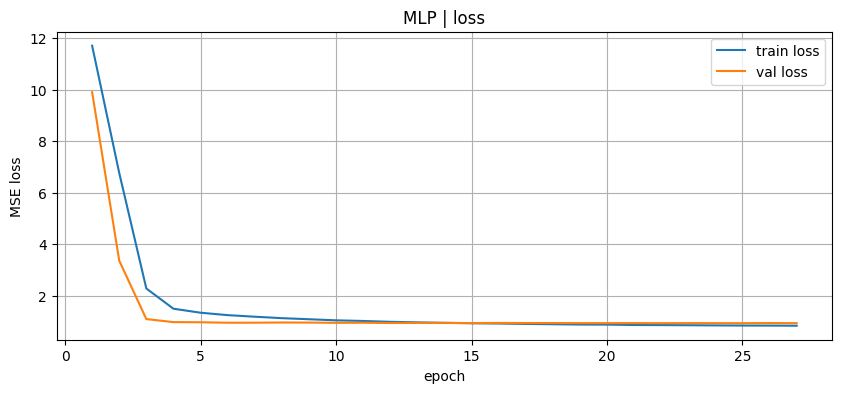

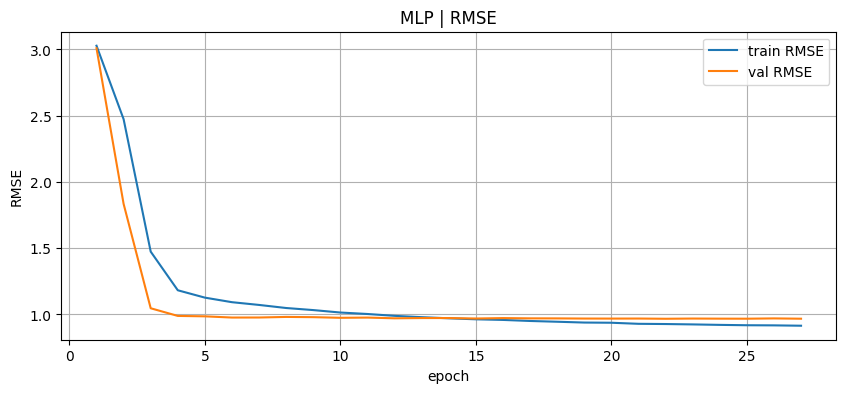

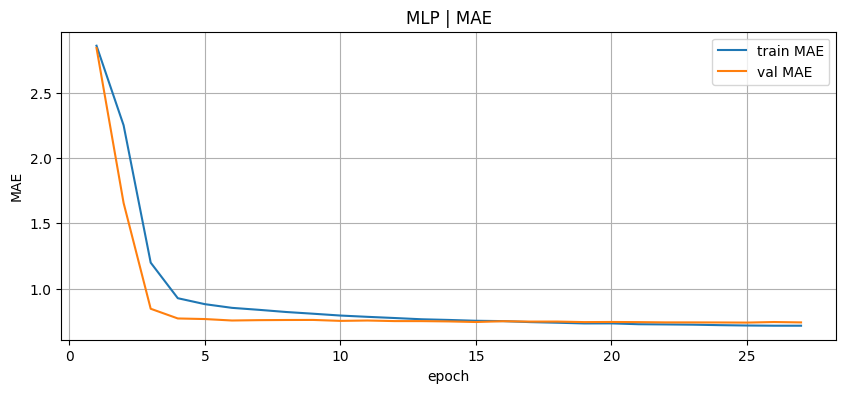

Test loss: 1.0295
Test RMSE: 1.0146
Test MAE:  0.8037


In [16]:
plot_history(mlp_history, title="MLP")

test_loss, test_rmse, test_mae = evaluate(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=DEVICE,
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE:  {test_mae:.4f}")

models_results = []

models_results.append({
    'name': 'MLP',
    'test_rmse': test_rmse,
    'test_mae': test_mae, 
    'random_state': RANDOM_STATE
})

## 3. Hybrid NeuralCF

Данная модель схожа с обычным MLP, однако в процессе обучения создает вектор неявных признаков, которые помогают найти скрытые связи между фильмами и пользователями. Наряду с этими признаками в модель будут поступать признаки, полученные в exp01.

### 3.1. Импорты

In [17]:
from torch.utils.data import TensorDataset

### 3.2. Предобработка данных

#### 3.2.1. Функции по обработке индексов

In [18]:
def make_id_mapping(values):
    """
    Создаёт словарь id -> index. Индекс 0 зарезервирован под unknown.
    """
    unique_values = pd.Series(values).dropna().unique()
    return {value: idx + 1 for idx, value in enumerate(unique_values)}


def map_with_unknown(values, mapping):
    """
    Переводит реальные id в индексы. Если id не было в train, возвращает 0.
    """
    return pd.Series(values).map(mapping).fillna(0).astype("int64").values

In [19]:
# Создем пары айди - индекс
user_mapping = make_id_mapping(train_df["userId"])
movie_mapping = make_id_mapping(train_df["movieId"])

# Заполняем нулями незнакомых пользователей и фильмы
train_user_idx = map_with_unknown(train_df["userId"], user_mapping)
val_user_idx = map_with_unknown(val_df["userId"], user_mapping)
test_user_idx = map_with_unknown(test_df["userId"], user_mapping)
train_movie_idx = map_with_unknown(train_df["movieId"], movie_mapping)
val_movie_idx = map_with_unknown(val_df["movieId"], movie_mapping)
test_movie_idx = map_with_unknown(test_df["movieId"], movie_mapping)

n_users = len(user_mapping) + 1
n_movies = len(movie_mapping) + 1

print("n_users:", n_users)
print("n_movies:", n_movies)

print("Unknown users in val:", (val_user_idx == 0).mean())
print("Unknown movies in val:", (val_movie_idx == 0).mean())
print("Unknown users in test:", (test_user_idx == 0).mean())
print("Unknown movies in test:", (test_movie_idx == 0).mean())

n_users: 454
n_movies: 7057
Unknown users in val: 0.8205077350257834
Unknown movies in val: 0.1639230464101547
Unknown users in test: 0.9568127727092424
Unknown movies in test: 0.2552062673542245


#### 3.2.2. Соединяем в единый датасет

In [20]:
X_train_hybrid = np.column_stack([
    train_movie_idx,
    X_train_scaled,
]).astype("float32")

X_val_hybrid = np.column_stack([
    val_movie_idx,
    X_val_scaled,
]).astype("float32")

X_test_hybrid = np.column_stack([
    test_movie_idx,
    X_test_scaled,
]).astype("float32")

#### 3.2.3. Преобразуем данные под torch

In [21]:
X_train_tensor = torch.tensor(X_train_hybrid, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_hybrid, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_hybrid, dtype=torch.float32)

#### 3.2.4. DataLoader

In [22]:
train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=2048,
    shuffle=True,
)

val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=4096,
    shuffle=False,
)

test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=4096,
    shuffle=False,
)

### 3.3. Класс NCF

In [23]:
class HybridMovieOnlyCF(nn.Module):
    def __init__(self, n_movies, n_dense_features, emb_dim=8, global_mean=3.5):
        super().__init__()

        self.movie_emb = nn.Embedding(n_movies, emb_dim)
        self.movie_bias = nn.Embedding(n_movies, 1)

        self.mlp = nn.Sequential(
            nn.Linear(emb_dim + n_dense_features, 64),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 1),
        )

        self.global_bias = nn.Parameter(
            torch.tensor([global_mean], dtype=torch.float32)
        )

    def forward(self, x):
        movie_idx = x[:, 0].long()
        dense_x = x[:, 1:].float()

        movie_vec = self.movie_emb(movie_idx)

        features = torch.cat([movie_vec, dense_x], dim=1)

        rating = (
            self.mlp(features)
            + self.movie_bias(movie_idx)
            + self.global_bias
        )

        return rating

### 3.4. Обучение

In [24]:
global_mean = train_df["rating"].mean()

model = HybridMovieOnlyCF(
    n_movies=n_movies,
    n_dense_features=X_train_scaled.shape[1],
    emb_dim=8,
    global_mean=global_mean,
).to(DEVICE)

nn.init.zeros_(model.movie_bias.weight)

criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-4,
    weight_decay=1e-4,
)

ncf_history, model = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=DEVICE,
    epochs=100,
    patience=10,
    verbose=True,
)

Epoch 01/100 | train loss 0.9959, RMSE 0.9979, MAE 0.7901 | val loss 1.0203, RMSE 1.0101, MAE 0.7876 | 1.2s
Epoch 02/100 | train loss 0.8840, RMSE 0.9402, MAE 0.7369 | val loss 0.9775, RMSE 0.9887, MAE 0.7637 | 1.0s
Epoch 03/100 | train loss 0.8488, RMSE 0.9213, MAE 0.7196 | val loss 0.9595, RMSE 0.9796, MAE 0.7531 | 1.1s
Epoch 04/100 | train loss 0.8292, RMSE 0.9106, MAE 0.7095 | val loss 0.9505, RMSE 0.9749, MAE 0.7474 | 1.0s
Epoch 05/100 | train loss 0.8180, RMSE 0.9044, MAE 0.7042 | val loss 0.9466, RMSE 0.9729, MAE 0.7442 | 1.2s
Epoch 06/100 | train loss 0.8103, RMSE 0.9002, MAE 0.6997 | val loss 0.9439, RMSE 0.9715, MAE 0.7427 | 0.9s
Epoch 07/100 | train loss 0.8035, RMSE 0.8964, MAE 0.6958 | val loss 0.9418, RMSE 0.9705, MAE 0.7426 | 1.1s
Epoch 08/100 | train loss 0.7987, RMSE 0.8937, MAE 0.6941 | val loss 0.9409, RMSE 0.9700, MAE 0.7411 | 0.9s
Epoch 09/100 | train loss 0.7945, RMSE 0.8914, MAE 0.6922 | val loss 0.9403, RMSE 0.9697, MAE 0.7402 | 1.2s
Epoch 10/100 | train loss 0.

### 3.5. Оценка

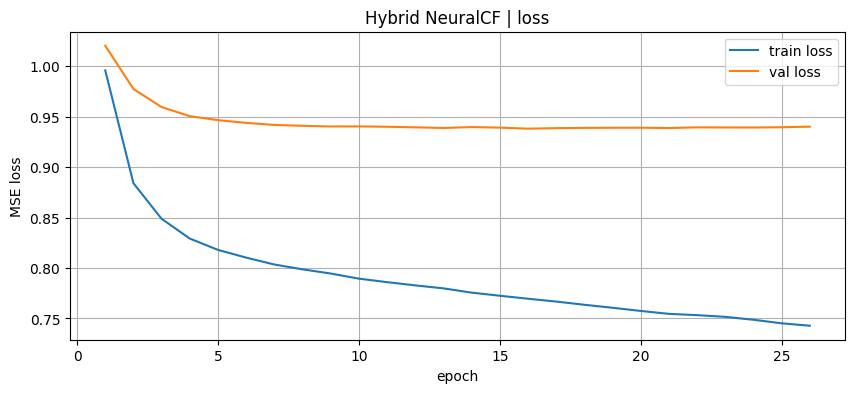

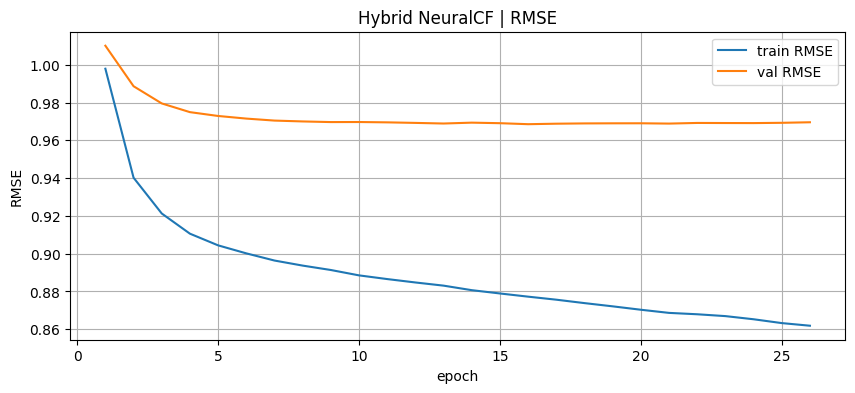

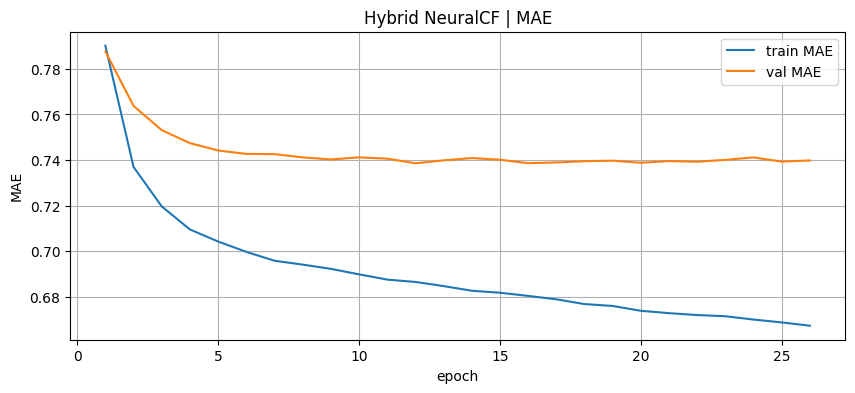

Test loss: 1.0219
Test RMSE: 1.0109
Test MAE:  0.7995


In [25]:
plot_history(ncf_history, title="Hybrid NeuralCF")

test_loss, test_rmse, test_mae = evaluate(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=DEVICE,
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE:  {test_mae:.4f}")

models_results.append({
    'name': 'NeuralCF',
    'test_rmse': test_rmse,
    'test_mae': test_mae, 
    'random_state': RANDOM_STATE
})

## 4. Сравнение моделей и анализ лучшей

In [26]:
results_df = pd.DataFrame(models_results)
results_df

,name,test_rmse,test_mae,random_state
0,MLP,1.014628,0.803652,42
1,NeuralCF,1.010899,0.799535,42


In [27]:
best_row = results_df.loc[results_df['test_rmse'].idxmin()]

best_params = best_row.to_dict()

best_params

{'name': 'NeuralCF',
 'test_rmse': 1.010898791368115,
 'test_mae': 0.7995345566964064,
 'random_state': 42}

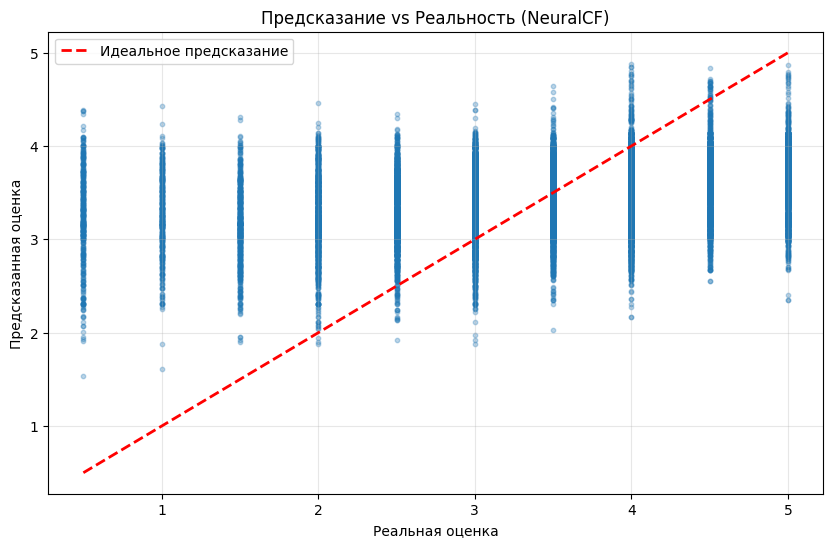

In [29]:
@torch.no_grad()
def get_model_predictions(model, loader, device, clip=True):
    model.eval()
    
    y_pred_list = []

    for x, y in loader:
        x = x.to(device)

        preds = model(x)

        if clip:
            preds = torch.clamp(preds, 0.5, 5.0)

        y_pred_list.append(preds.cpu().numpy().reshape(-1))

    y_pred = np.concatenate(y_pred_list)

    return y_pred

y_pred = get_model_predictions(model, test_loader, DEVICE)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_test, y_pred, alpha=0.3, s=10)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальное предсказание')
ax.set_xlabel('Реальная оценка')
ax.set_ylabel('Предсказанная оценка')
ax.set_title(f'Предсказание vs Реальность (NeuralCF)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 5. Артефакты

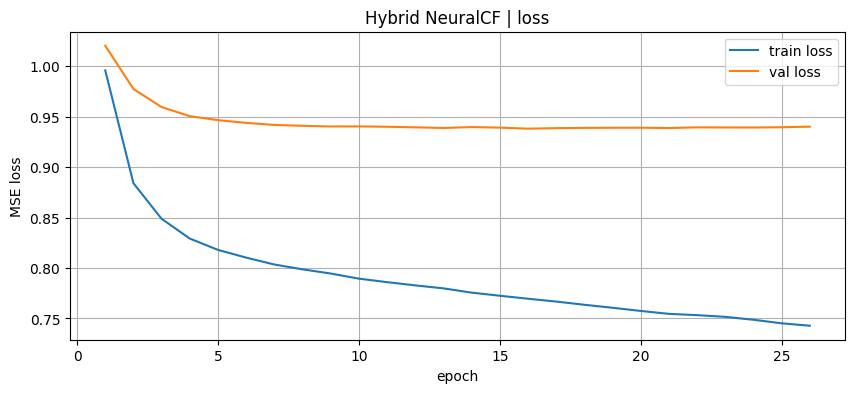

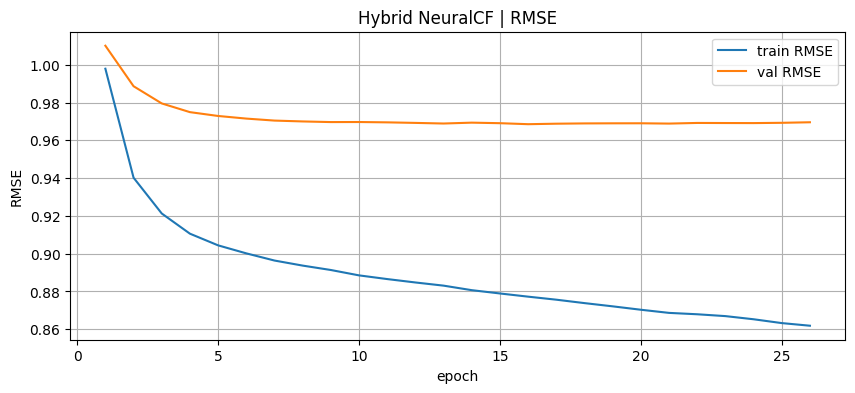

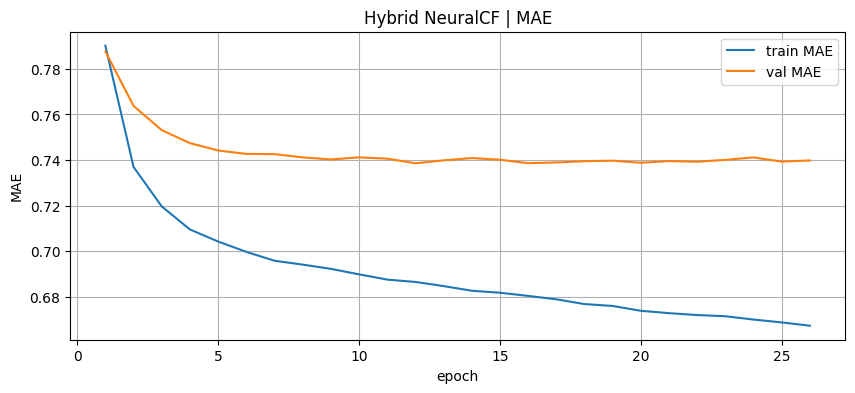

In [33]:
import json

artifacts_path = os.path.join('..', 'artifacts', 'exp04')
os.makedirs(artifacts_path, exist_ok=True)

figures_path = os.path.join(artifacts_path, 'figures')
os.makedirs(figures_path, exist_ok=True)

results_df.to_csv(os.path.join(artifacts_path, 'runs.csv'), index=False)

with open(os.path.join(artifacts_path, 'best_model_params.json'), 'w') as f:
    json.dump(best_params, f, indent=4)

fig.savefig(os.path.join(figures_path, 'prediction_vs_actual.png'), dpi=150, bbox_inches='tight')

plot_history(ncf_history, title="Hybrid NeuralCF", save_path = figures_path)

## 6. Заключение

По итогу эксперимента нейросети также не смогли дать сильного результата. Это обусловленно огромной долей новых пользователей в валидационной и тестовой частях. Поэтому модели работают с усредненными данными и сильно не отличаются от безлайна, ставящего среднюю оценку.